<a href="https://colab.research.google.com/github/202422/Startup-Operational-Status-prediction-using-Machine-learning/blob/work_branch/Feature_engineering/feature_engineering_startup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import xgboost as xgb
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import joblib

In [2]:
df_company = pd.read_csv("/content/company_explored_df.csv")

In [3]:
df_company

,category_code,status,founded_at,active_days,country_code,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lat,lng,isClosed
0,advertising,operating,2007,5114,other,2010.0,2011.0,1.0,4587548.0,2009.0,2010.0,1.0,2.0,30.427755,-9.598107,0
1,other,operating,2008,4749,IND,2010.0,2011.0,1.0,4587548.0,2009.0,2010.0,1.0,4.0,22.307159,73.181219,0
2,advertising,operating,2008,4749,USA,2010.0,2011.0,1.0,4587548.0,2008.0,2008.0,1.0,2.0,35.686975,-105.937799,0
3,games_video,operating,2008,4749,USA,2010.0,2011.0,1.0,4587548.0,2008.0,2008.0,1.0,3.0,33.078655,-116.601964,0
4,software,operating,2011,3653,AUS,2010.0,2011.0,1.0,4587548.0,2011.0,2011.0,1.0,2.0,49.050438,-122.304470,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44073,web,operating,2006,5479,other,2010.0,2011.0,1.0,4587548.0,2009.0,2010.0,1.0,4.0,35.185566,33.382276,0
44074,other,operating,2008,4749,USA,2010.0,2011.0,1.0,4587548.0,2011.0,2011.0,1.0,5.0,38.846224,-77.306373,0
44075,software,operating,2004,6210,USA,2010.0,2011.0,1.0,4587548.0,2009.0,2010.0,1.0,4.0,40.748350,-74.323219,0
44076,ecommerce,operating,2007,5114,USA,2010.0,2011.0,1.0,4587548.0,2013.0,2013.0,2.0,5.0,37.774929,-122.419415,0


In [4]:
num_feat = ["founded_at","active_days","first_funding_at","last_funding_at","funding_rounds","funding_total_usd","first_milestone_at","last_milestone_at","milestones","relationships","lat","lng"]
cat_feat = ["category_code","country_code","isClosed"]
target = ["status"]

..............................................................................................................

#  Feature Engineering

## 1) Feature selection
   a) Numerical features
  
   b) Categorical features
## 2) Log transformation and standardisation
   a) Log transformation
   
   b) Standardisation

## 3) Creation of new features



## 4) Feature encoding
   a) Target
   
   b) Categorical features

## 5) Feature engineering Documentation

............................................................................................................

## 1) Feature selection

### a) Numerical  features

#### Dependancy test

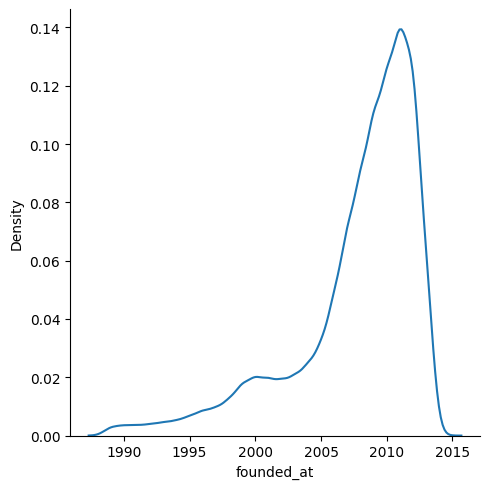

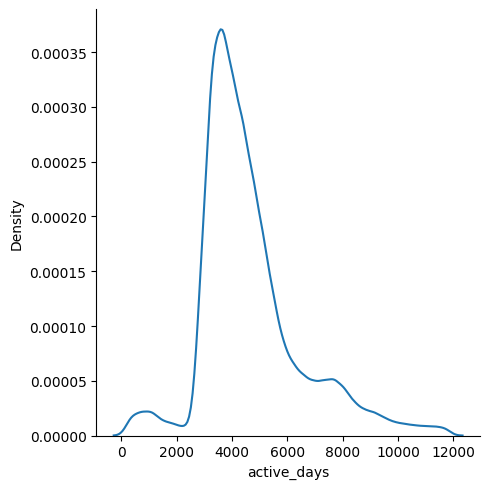

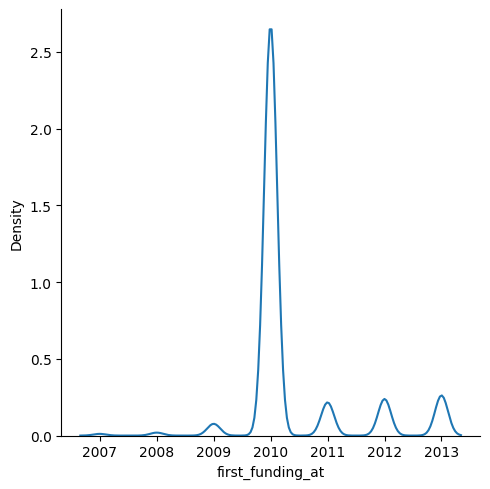

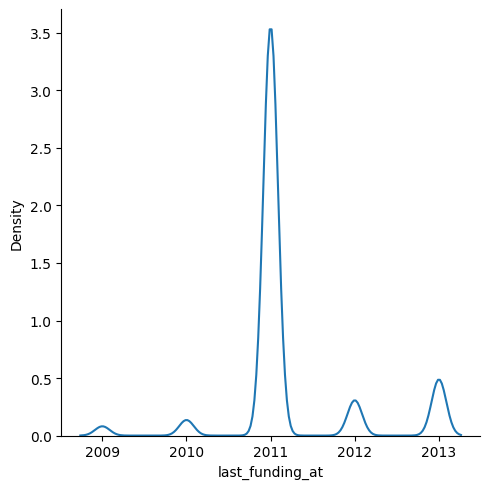

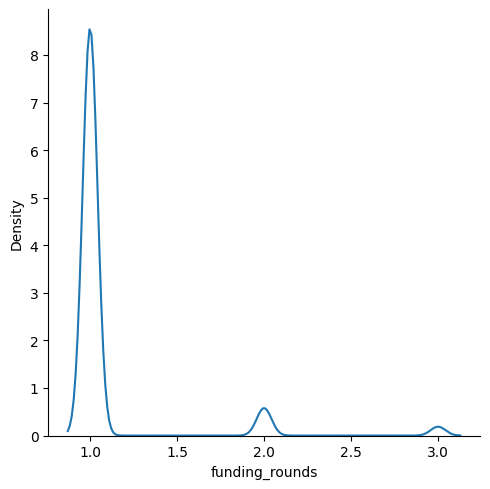

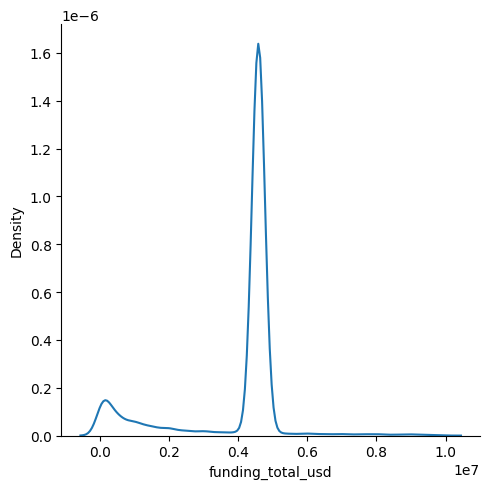

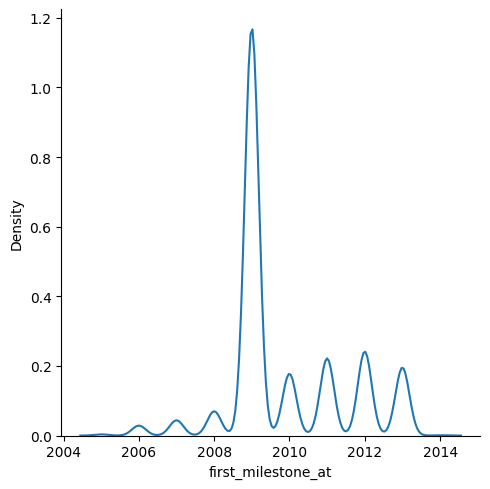

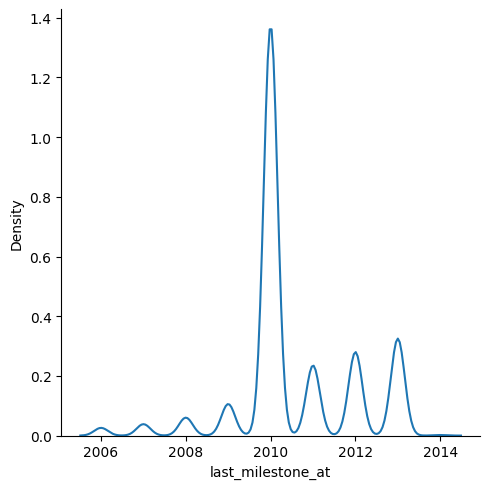

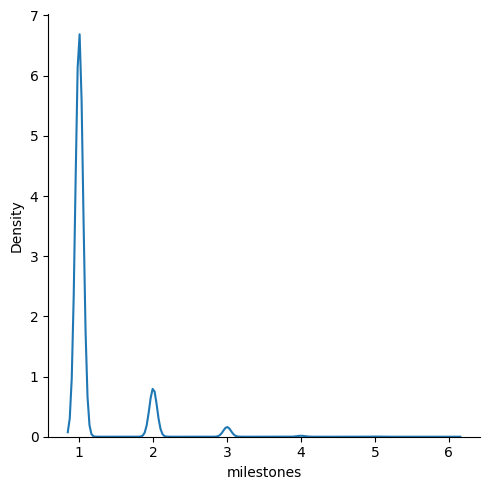

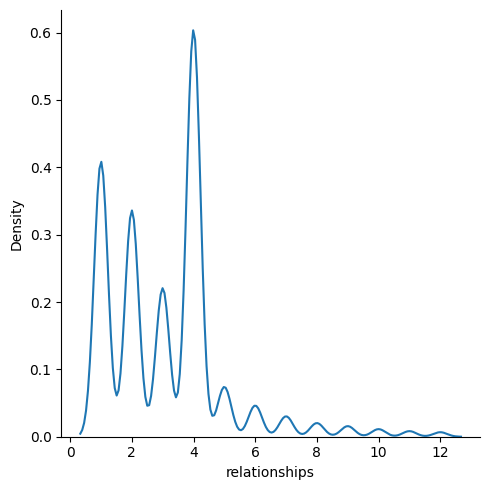

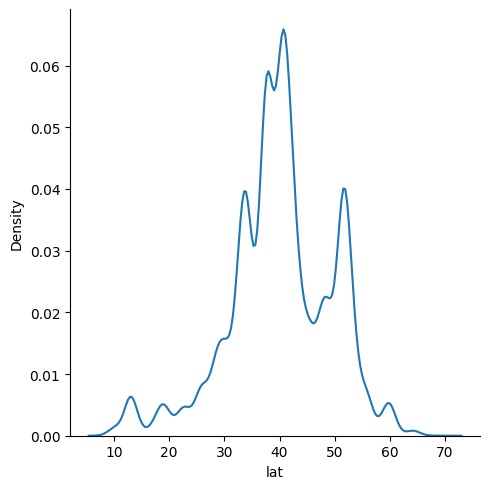

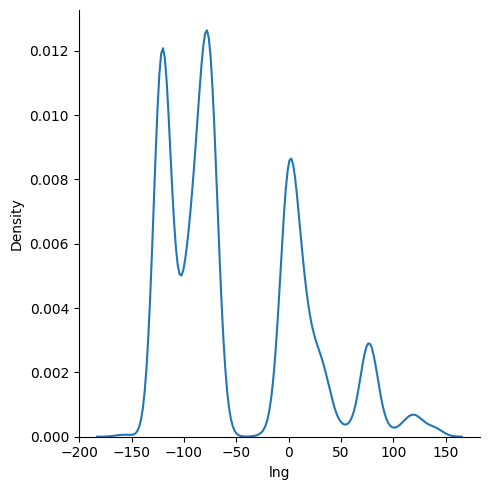

In [5]:
# Verifying the distribution of numerical features
for col in num_feat:
    sns.displot(data = df_company, x = col, kind = "kde")

In [6]:
# Applying Kruskal-Wallis test
stat = []
for col in num_feat:
    statis, pvalue = stats.kruskal(df_company.loc[df_company["status"]=="operating",col],df_company.loc[df_company["status"]=="closed",col],df_company.loc[df_company["status"]=="ipo",col],df_company.loc[df_company["status"]=="acquired",col])
    stat.append([col,pvalue,statis])

In [7]:
stat_df = pd.DataFrame(data = stat, columns = ["Name","P_value","Statistic"])
stat_df.sort_values(by = "P_value", ascending = True, inplace =True)
stat_df

,Name,P_value,Statistic
1,active_days,0.000000e+00,3266.019388
0,founded_at,9.714938e-253,1167.173196
3,last_funding_at,1.150414e-179,830.317850
8,milestones,1.794258e-149,691.090751
5,funding_total_usd,2.325653e-133,616.775791
2,first_funding_at,1.852758e-64,298.752234
11,lng,6.650666e-57,263.836552
9,relationships,3.399183e-43,200.434055
4,funding_rounds,2.188249e-32,150.373955
6,first_milestone_at,2.351684e-24,113.108036


#### Feature importance

In [8]:
# Encoding target variable
lbenc = LabelEncoder()
targ_var = lbenc.fit_transform(df_company[target])
targ_var

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([3, 3, 3, ..., 3, 3, 3])

In [9]:
np.unique(targ_var)

array([0, 1, 2, 3])

In [10]:
# Training Random Forest Classifier model
rdf_class = RandomForestClassifier(n_estimators=100, random_state=42)
rdf_class.fit(df_company[num_feat],targ_var)

RandomForestClassifier(random_state=42)

In [11]:
accuracy_score(targ_var,rdf_class.predict(df_company[num_feat]))

0.9998185035618676

In [12]:
feat_import_df1 = pd.DataFrame(data = rdf_class.feature_importances_, columns = ["feat_score"])
feat_import_df1.insert(0,"Name",num_feat)
feat_import_df1.sort_values(by = "feat_score", ascending = False)

,Name,feat_score
1,active_days,0.681913
0,founded_at,0.106145
11,lng,0.038664
10,lat,0.036417
5,funding_total_usd,0.031022
9,relationships,0.023061
7,last_milestone_at,0.018001
6,first_milestone_at,0.017185
3,last_funding_at,0.015454
2,first_funding_at,0.014083


In [13]:
# Training XGBOOST model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(df_company[num_feat], targ_var)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [16:12:33] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [14]:
accuracy_score(targ_var,xgb_model.predict(df_company[num_feat]))

0.9992286401379373

In [15]:
feat_import_df2 = pd.DataFrame(data = xgb_model.feature_importances_, columns = ["feat_score"])
feat_import_df2.insert(0,"Name",num_feat)
feat_import_df2.sort_values(by = "feat_score", ascending = False)

,Name,feat_score
1,active_days,0.661614
0,founded_at,0.098946
8,milestones,0.039921
5,funding_total_usd,0.039551
7,last_milestone_at,0.030274
6,first_milestone_at,0.025960
3,last_funding_at,0.021454
4,funding_rounds,0.017078
9,relationships,0.016918
10,lat,0.016328


In [16]:
df_company2 = df_company.drop(["funding_rounds","lat"], axis = 1)

In [17]:
num_feat.remove("funding_rounds")
num_feat.remove("lat")

### b) Categorical  features

In [18]:
# Applying Khi square and V-cramer test
stat_cat = []
for var in cat_feat:
    contingency_table = pd.crosstab(df_company2[var],df_company2["status"])
    chi2 = stats.chi2_contingency(contingency_table)[0]
    p_value = stats.chi2_contingency(contingency_table)[1]
    num_rows, num_cols = contingency_table.shape
    v_cramer = np.sqrt(chi2/(df_company2.shape[0]*min(num_rows-1,num_cols-1)))
    stat_cat.append([var,p_value,chi2,v_cramer])

In [19]:
stat_cat_df = pd.DataFrame(data = stat_cat, columns = ["Variable","P_Value","Chi_square","V_Cramer"])
stat_cat_df.sort_values(by = "P_Value", ascending = True, inplace = True)
stat_cat_df

,Variable,P_Value,Chi_square,V_Cramer
2,isClosed,0.000000e+00,44078.000000,1.000000
0,category_code,4.676510e-94,536.076966,0.063671
1,country_code,2.279751e-60,370.655299,0.052944


## 2) Log Transformation and Standardisation

### a) Log Transformation

<Figure size 1000x800 with 0 Axes>

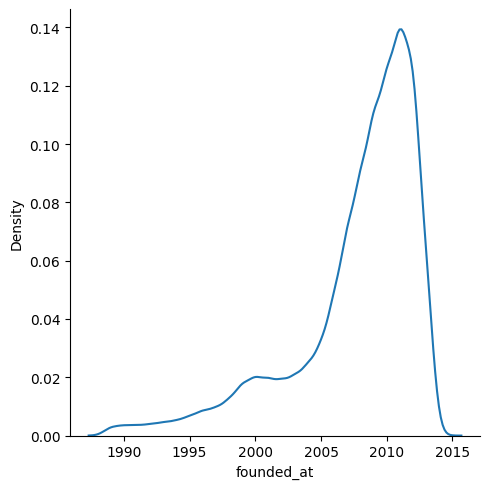

<Figure size 1000x800 with 0 Axes>

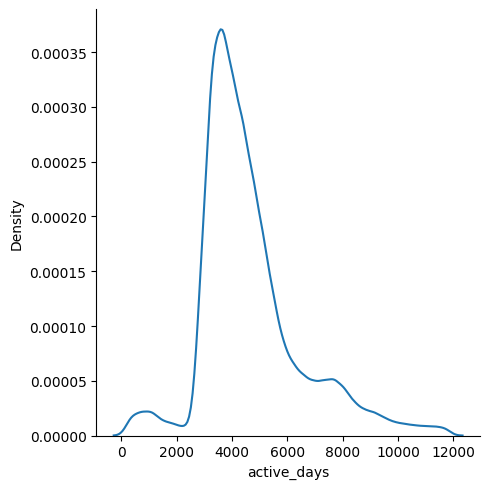

<Figure size 1000x800 with 0 Axes>

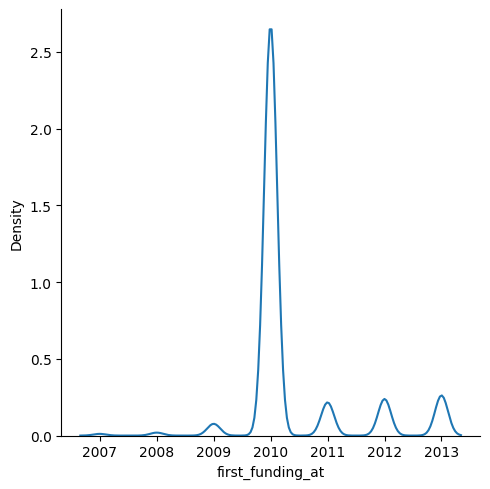

<Figure size 1000x800 with 0 Axes>

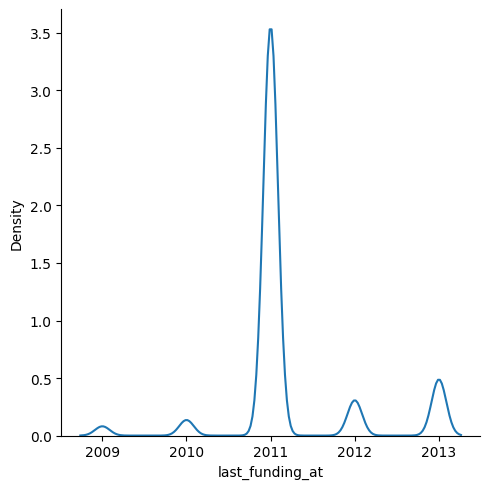

<Figure size 1000x800 with 0 Axes>

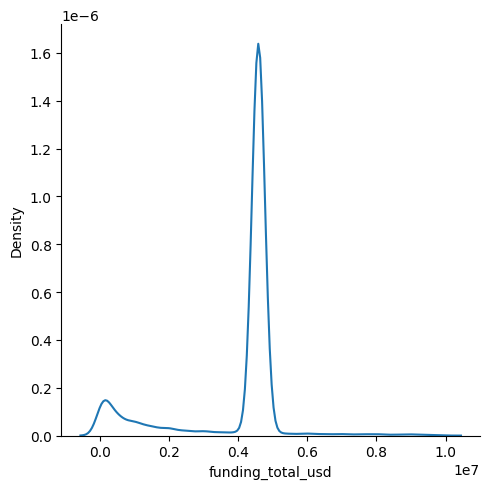

<Figure size 1000x800 with 0 Axes>

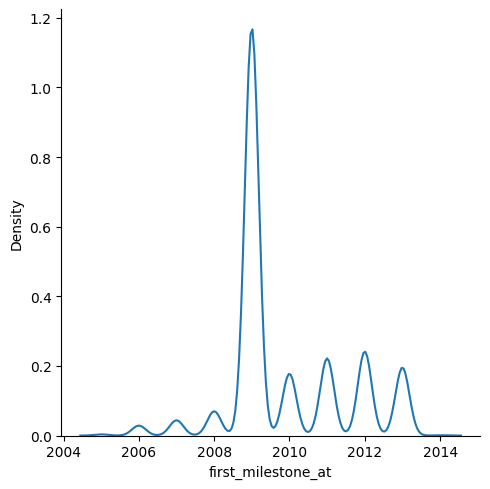

<Figure size 1000x800 with 0 Axes>

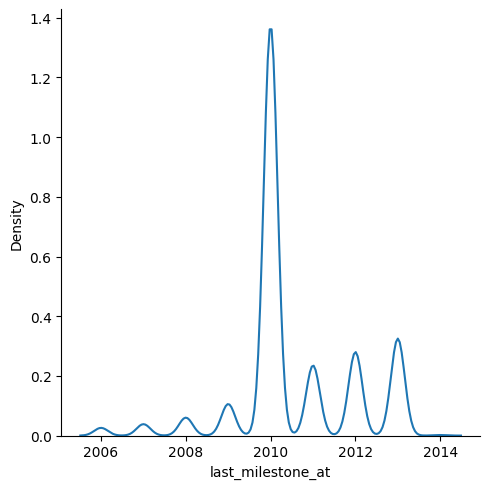

<Figure size 1000x800 with 0 Axes>

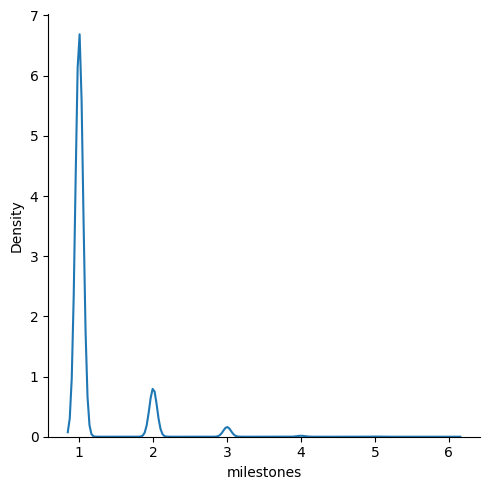

<Figure size 1000x800 with 0 Axes>

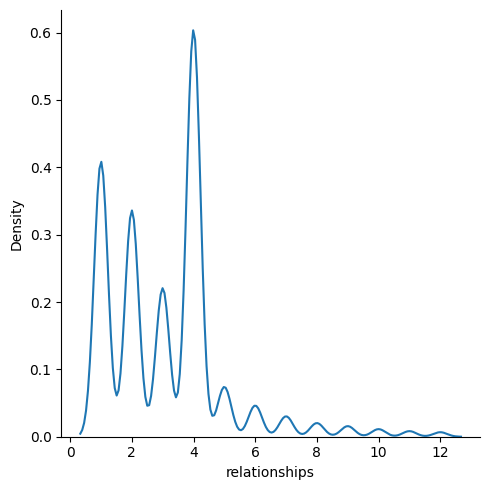

<Figure size 1000x800 with 0 Axes>

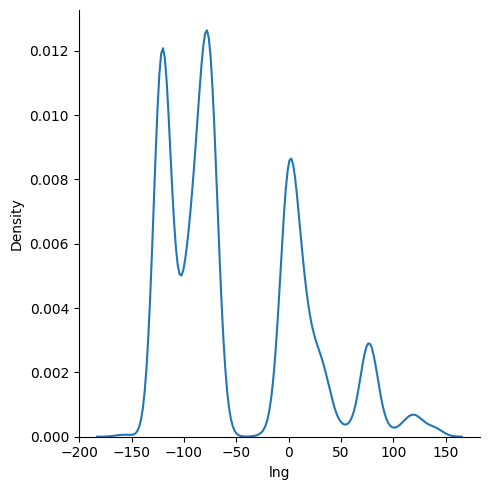

In [20]:
for col in num_feat:
    plt.figure(figsize = (10,8))
    sns.displot(data = df_company2, kind = "kde", x = col)

In [21]:
#defining log transformation function
def logfunct(x):
    df_company2[x] = np.log1p(df_company2[x])

In [22]:
# Operating transformation
for var in num_feat:
    if abs(df_company2[var].skew())>1:
        logfunct(var)
        print(var)

founded_at
active_days
first_funding_at
funding_total_usd
milestones
relationships


<Figure size 1000x800 with 0 Axes>

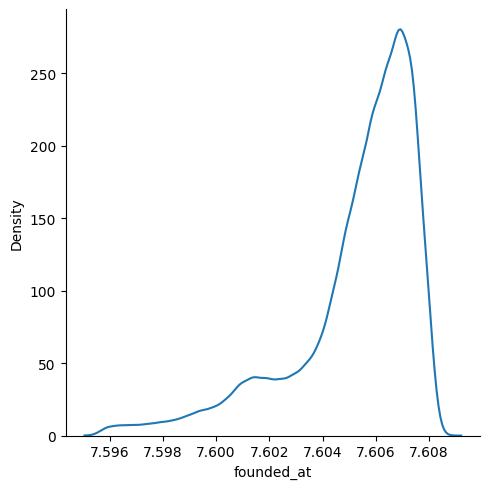

<Figure size 1000x800 with 0 Axes>

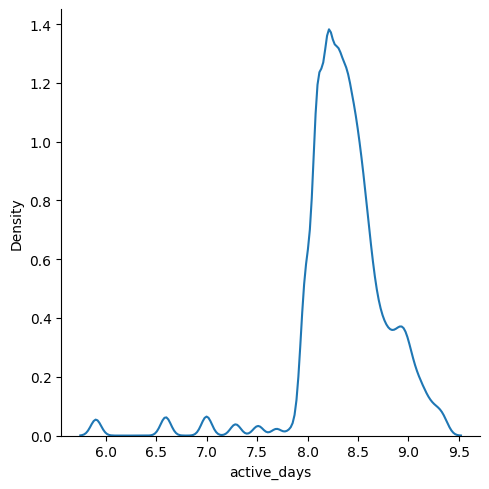

<Figure size 1000x800 with 0 Axes>

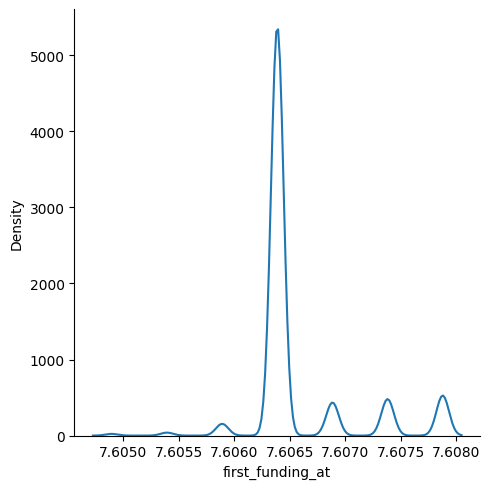

<Figure size 1000x800 with 0 Axes>

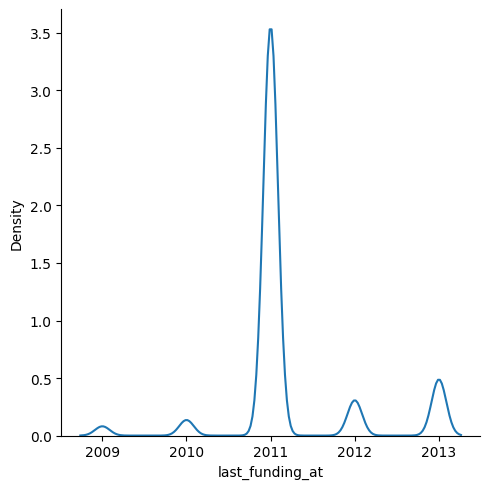

<Figure size 1000x800 with 0 Axes>

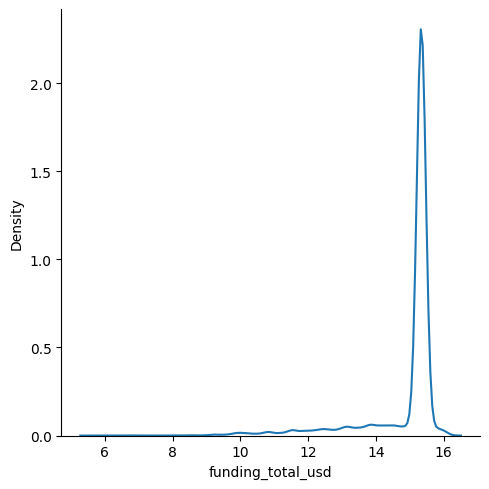

<Figure size 1000x800 with 0 Axes>

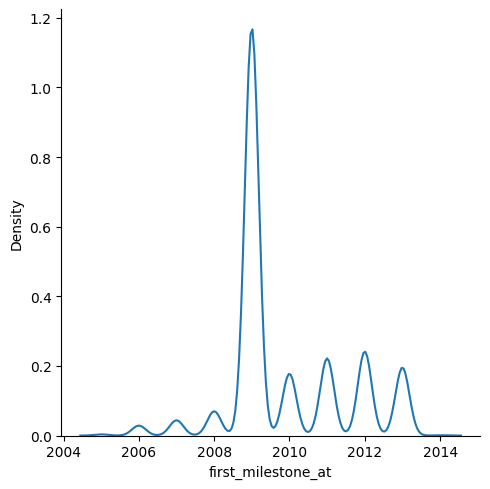

<Figure size 1000x800 with 0 Axes>

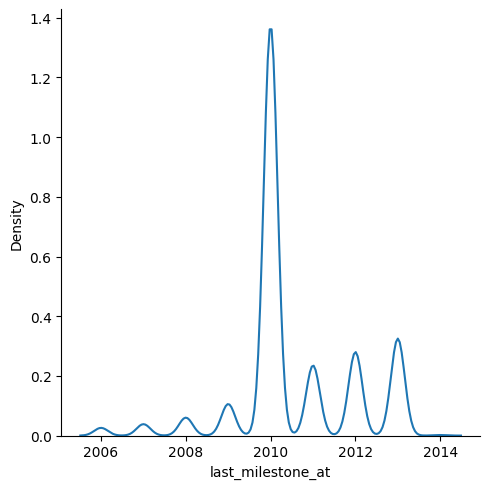

<Figure size 1000x800 with 0 Axes>

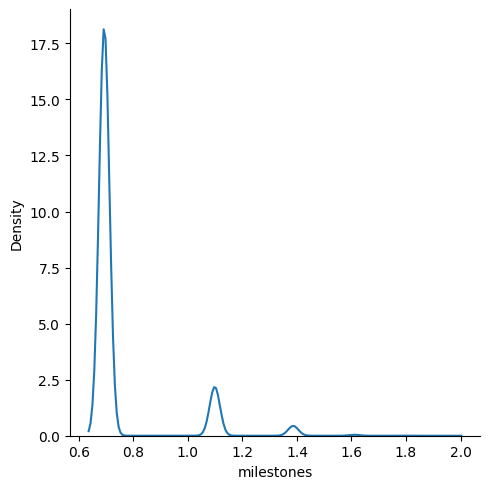

<Figure size 1000x800 with 0 Axes>

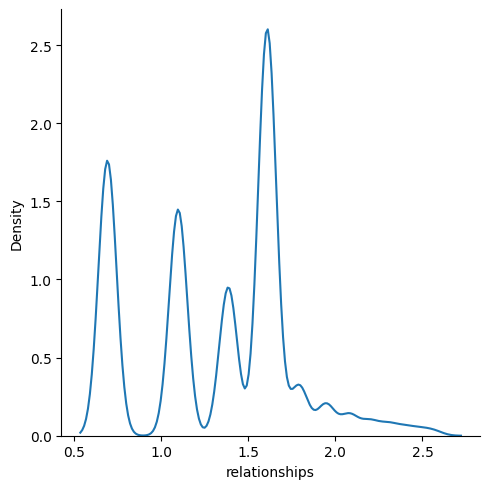

<Figure size 1000x800 with 0 Axes>

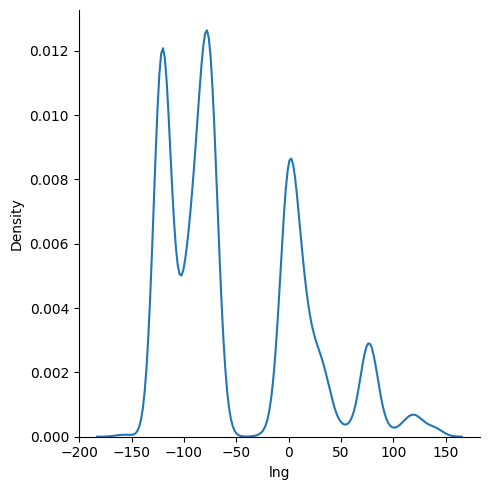

In [23]:
for col in num_feat:
    plt.figure(figsize = (10,8))
    sns.displot(data = df_company2, kind = "kde", x = col)

### b) Standardisation

In [24]:
std = StandardScaler().set_output(transform = "pandas")
std_df = std.fit_transform(df_company2[num_feat])
std_df

,founded_at,active_days,first_funding_at,last_funding_at,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lng
0,-0.161184,0.403698,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,-0.514252,0.633597
1,0.048769,0.233583,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.881706
2,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,-0.514252,-0.818970
3,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,0.138444,-0.979759
4,0.678003,-0.369189,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,-0.514252,-1.065739
...,...,...,...,...,...,...,...,...,...,...
44073,-0.371242,0.562082,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.281636
44074,0.048769,0.233583,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,1.058366,-0.387278
44075,-0.791673,0.849809,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,-0.342299
44076,-0.161184,0.403698,-0.392899,-0.291683,0.384564,1.992176,1.773511,2.138829,1.058366,-1.067472


In [25]:
df_company2.drop(num_feat, axis = 1, inplace = True)
df_company2

,category_code,status,country_code,isClosed
0,advertising,operating,other,0
1,other,operating,IND,0
2,advertising,operating,USA,0
3,games_video,operating,USA,0
4,software,operating,AUS,0
...,...,...,...,...
44073,web,operating,other,0
44074,other,operating,USA,0
44075,software,operating,USA,0
44076,ecommerce,operating,USA,0


In [26]:
df_company_scaled = pd.concat([df_company2,std_df], axis = 1, ignore_index = False)
df_company_scaled

,category_code,status,country_code,isClosed,founded_at,active_days,first_funding_at,last_funding_at,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lng
0,advertising,operating,other,0,-0.161184,0.403698,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,-0.514252,0.633597
1,other,operating,IND,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.881706
2,advertising,operating,USA,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,-0.514252,-0.818970
3,games_video,operating,USA,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,0.138444,-0.979759
4,software,operating,AUS,0,0.678003,-0.369189,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,-0.514252,-1.065739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44073,web,operating,other,0,-0.371242,0.562082,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.281636
44074,other,operating,USA,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,1.058366,-0.387278
44075,software,operating,USA,0,-0.791673,0.849809,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,-0.342299
44076,ecommerce,operating,USA,0,-0.161184,0.403698,-0.392899,-0.291683,0.384564,1.992176,1.773511,2.138829,1.058366,-1.067472


<Figure size 1000x800 with 0 Axes>

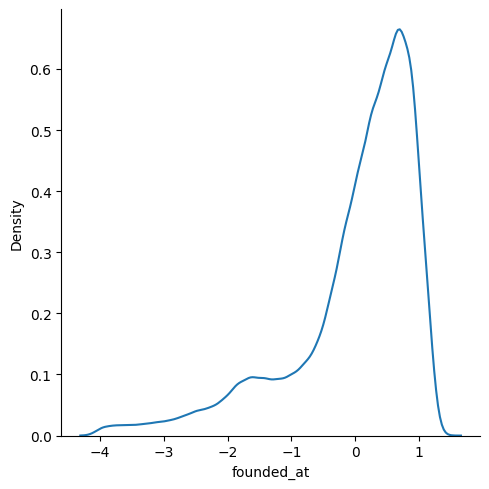

<Figure size 1000x800 with 0 Axes>

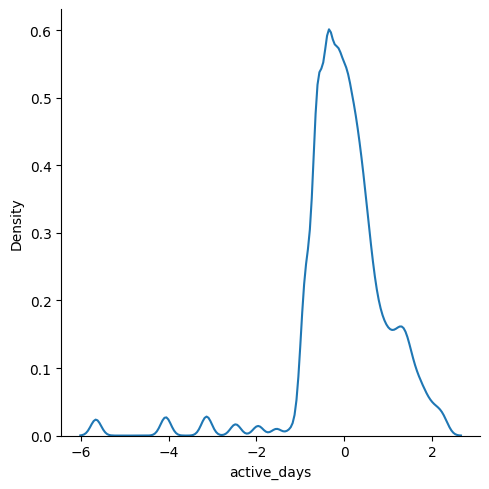

<Figure size 1000x800 with 0 Axes>

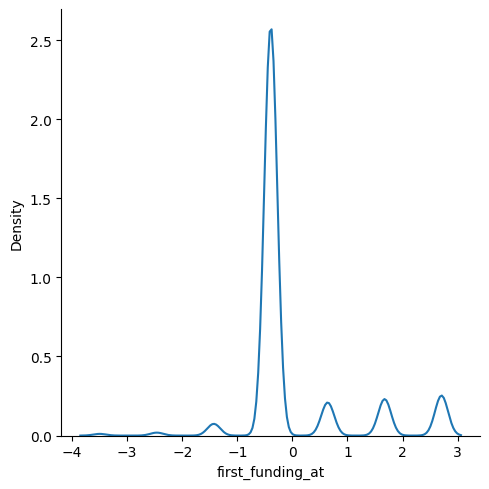

<Figure size 1000x800 with 0 Axes>

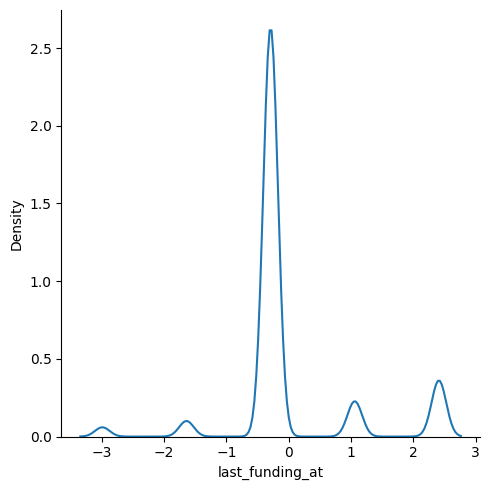

<Figure size 1000x800 with 0 Axes>

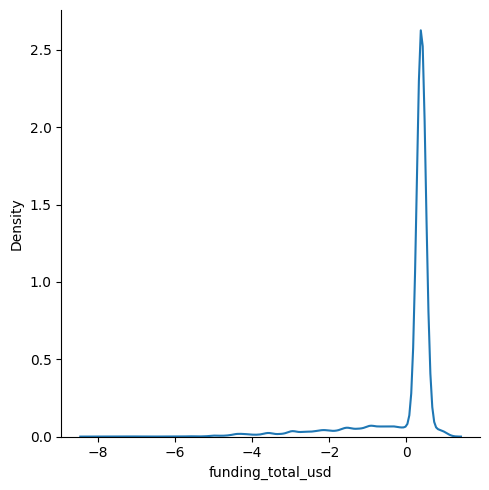

<Figure size 1000x800 with 0 Axes>

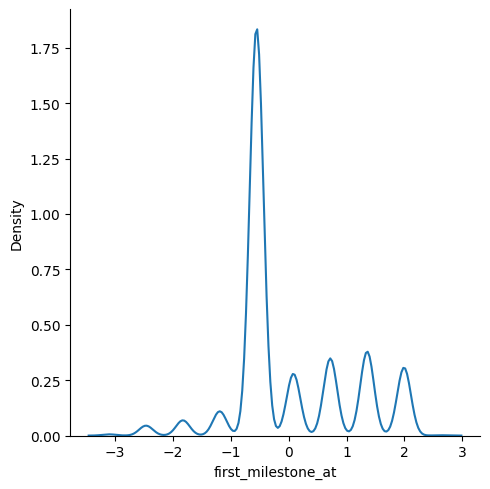

<Figure size 1000x800 with 0 Axes>

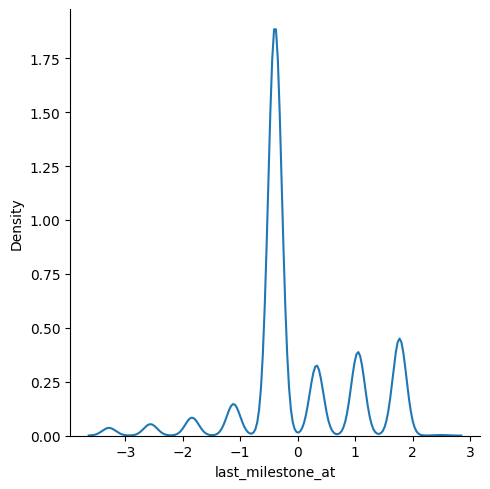

<Figure size 1000x800 with 0 Axes>

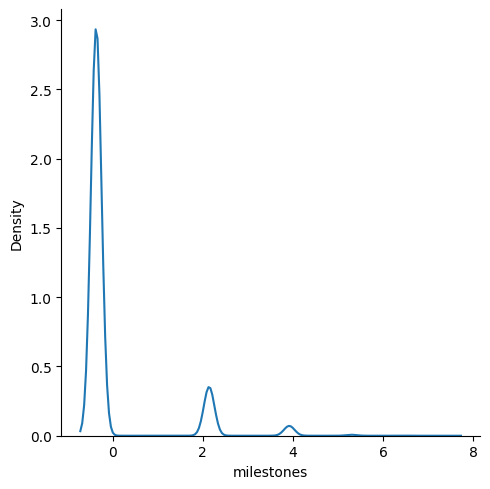

<Figure size 1000x800 with 0 Axes>

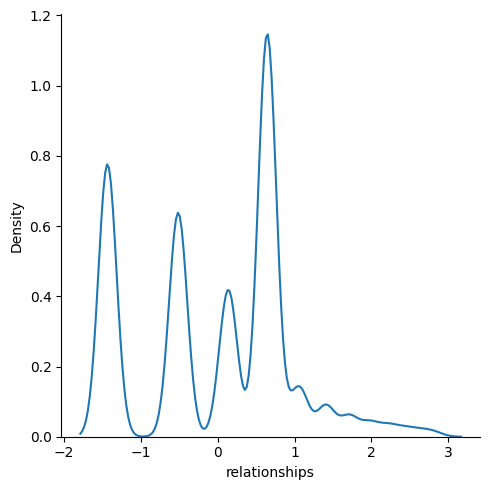

<Figure size 1000x800 with 0 Axes>

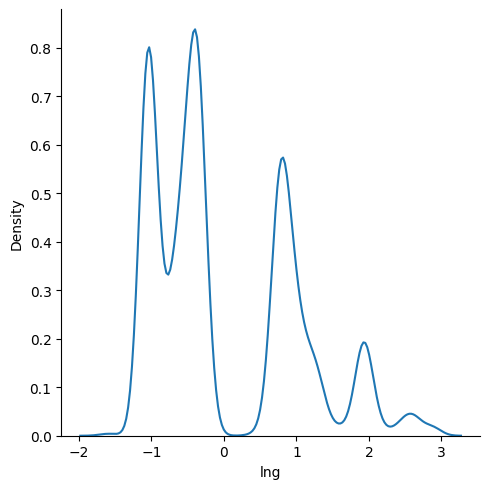

In [27]:
for col in num_feat:
    plt.figure(figsize = (10,8))
    sns.displot(data = df_company_scaled, kind = "kde", x = col)

## 3) Creation of new features/ Adding interaction terms

In [28]:
num_feat

['founded_at',
 'active_days',
 'first_funding_at',
 'last_funding_at',
 'funding_total_usd',
 'first_milestone_at',
 'last_milestone_at',
 'milestones',
 'relationships',
 'lng']

In [29]:
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
poly_feat = poly.fit_transform(df_company_scaled[num_feat])
poly_feat

array([[-0.16118421,  0.40369765, -0.39289879, ...,  0.18871038,
        -0.23250548, -0.32582829],
       [ 0.04876925,  0.23358295, -0.39289879, ..., -0.23658488,
        -0.69051317,  1.21316194],
       [ 0.04876925,  0.23358295, -0.39289879, ...,  0.18871038,
         0.30053004,  0.42115648],
       ...,
       [-0.79167252,  0.84980865, -0.39289879, ..., -0.23658488,
         0.12561051, -0.22068498],
       [-0.16118421,  0.40369765, -0.39289879, ...,  2.26366508,
        -2.28314062, -1.12977646],
       [ 0.04876925,  0.23358295, -0.39289879, ...,  0.52628622,
         0.36861697,  1.44064554]])

In [30]:
# Creating a dataframe that contains input features with interactions terms
columns = poly.get_feature_names_out(num_feat)
df_interact = pd.DataFrame(poly_feat, columns=columns)
df_interact

,founded_at,active_days,first_funding_at,last_funding_at,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lng,...,first_milestone_at last_milestone_at,first_milestone_at milestones,first_milestone_at relationships,first_milestone_at lng,last_milestone_at milestones,last_milestone_at relationships,last_milestone_at lng,milestones relationships,milestones lng,relationships lng
0,-0.161184,0.403698,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,-0.514252,0.633597,...,0.218221,0.203275,0.284865,-0.350976,0.144562,0.202586,-0.249601,0.188710,-0.232505,-0.325828
1,0.048769,0.233583,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.881706,...,0.218221,0.203275,-0.357134,-1.042355,0.144562,-0.253980,-0.741284,-0.236585,-0.690513,1.213162
2,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,-0.514252,-0.818970,...,2.189171,0.436857,0.612202,0.974960,0.674809,0.945663,1.506013,0.188710,0.300530,0.421156
3,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,0.138444,-0.979759,...,2.189171,0.436857,-0.164813,1.166375,0.674809,-0.254586,1.801690,-0.050803,0.359534,-0.135642
4,0.678003,-0.369189,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,-0.514252,-1.065739,...,0.236260,-0.263888,-0.369807,-0.766391,-0.120562,-0.168953,-0.350140,0.188710,0.391085,0.548058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44073,-0.371242,0.562082,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.281636,...,0.218221,0.203275,-0.357134,-0.709951,0.144562,-0.253980,-0.504891,-0.236585,-0.470311,0.826288
44074,0.048769,0.233583,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,1.058366,-0.387278,...,0.236260,-0.263888,0.761090,-0.278498,-0.120562,0.347718,-0.127237,-0.388379,0.142116,-0.409882
44075,-0.791673,0.849809,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,-0.342299,...,0.218221,0.203275,-0.357134,0.189614,0.144562,-0.253980,0.134846,-0.236585,0.125611,-0.220685
44076,-0.161184,0.403698,-0.392899,-0.291683,0.384564,1.992176,1.773511,2.138829,1.058366,-1.067472,...,3.533147,4.260925,2.108452,-2.126592,3.793238,1.877025,-1.893174,2.263665,-2.283141,-1.129776


In [31]:
df_interact.columns

Index(['founded_at', 'active_days', 'first_funding_at', 'last_funding_at',
       'funding_total_usd', 'first_milestone_at', 'last_milestone_at',
       'milestones', 'relationships', 'lng', 'founded_at active_days',
       'founded_at first_funding_at', 'founded_at last_funding_at',
       'founded_at funding_total_usd', 'founded_at first_milestone_at',
       'founded_at last_milestone_at', 'founded_at milestones',
       'founded_at relationships', 'founded_at lng',
       'active_days first_funding_at', 'active_days last_funding_at',
       'active_days funding_total_usd', 'active_days first_milestone_at',
       'active_days last_milestone_at', 'active_days milestones',
       'active_days relationships', 'active_days lng',
       'first_funding_at last_funding_at',
       'first_funding_at funding_total_usd',
       'first_funding_at first_milestone_at',
       'first_funding_at last_milestone_at', 'first_funding_at milestones',
       'first_funding_at relationships', 'first_fun

<Axes: >

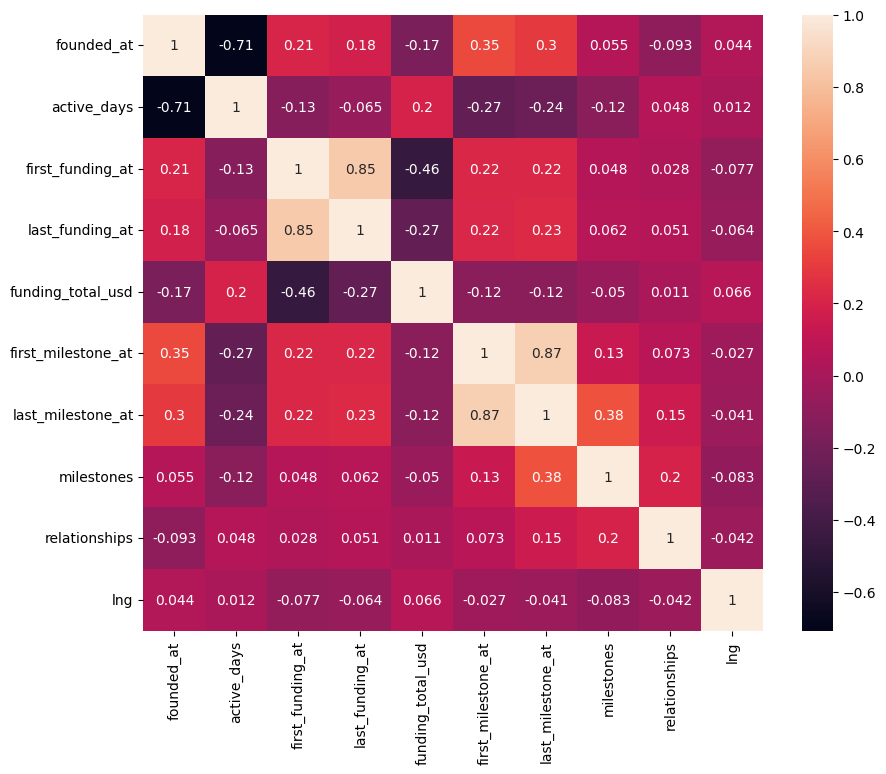

In [32]:
# Displaying heatmap of features' correlation in order to select the bests interaction terms
plt.figure(figsize = (10,8))
sns.heatmap(df_company_scaled[num_feat].corr(method = "pearson"), annot = True)

In [33]:
# Selecting features and bests interaction terms
df_interact = df_interact[['founded_at', 'active_days', 'first_funding_at', 'last_funding_at','funding_total_usd',
                           'first_milestone_at','last_milestone_at','milestones', 'relationships', 'lng',
                           'founded_at active_days','first_funding_at last_milestone_at','first_funding_at funding_total_usd',
                           'first_milestone_at last_milestone_at']]

In [34]:
df_interact

,founded_at,active_days,first_funding_at,last_funding_at,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lng,founded_at active_days,first_funding_at last_milestone_at,first_funding_at funding_total_usd,first_milestone_at last_milestone_at
0,-0.161184,0.403698,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,-0.514252,0.633597,-0.065070,0.154780,-0.151095,0.218221
1,0.048769,0.233583,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.881706,0.011392,0.154780,-0.151095,0.218221
2,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,-0.514252,-0.818970,0.011392,0.722506,-0.151095,2.189171
3,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,0.138444,-0.979759,0.011392,0.722506,-0.151095,2.189171
4,0.678003,-0.369189,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,-0.514252,-1.065739,-0.250311,-0.129084,-0.151095,0.236260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44073,-0.371242,0.562082,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.281636,-0.208669,0.154780,-0.151095,0.218221
44074,0.048769,0.233583,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,1.058366,-0.387278,0.011392,-0.129084,-0.151095,0.236260
44075,-0.791673,0.849809,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,-0.342299,-0.672770,0.154780,-0.151095,0.218221
44076,-0.161184,0.403698,-0.392899,-0.291683,0.384564,1.992176,1.773511,2.138829,1.058366,-1.067472,-0.065070,-0.696810,-0.151095,3.533147


In [35]:
# Concatening interaction terms to old dataframe
df_company_interact = pd.concat([df_company_scaled.drop(num_feat, axis = 1),df_interact], axis = 1, ignore_index = False)
df_company_interact

,category_code,status,country_code,isClosed,founded_at,active_days,first_funding_at,last_funding_at,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lng,founded_at active_days,first_funding_at last_milestone_at,first_funding_at funding_total_usd,first_milestone_at last_milestone_at
0,advertising,operating,other,0,-0.161184,0.403698,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,-0.514252,0.633597,-0.065070,0.154780,-0.151095,0.218221
1,other,operating,IND,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.881706,0.011392,0.154780,-0.151095,0.218221
2,advertising,operating,USA,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,-0.514252,-0.818970,0.011392,0.722506,-0.151095,2.189171
3,games_video,operating,USA,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,0.138444,-0.979759,0.011392,0.722506,-0.151095,2.189171
4,software,operating,AUS,0,0.678003,-0.369189,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,-0.514252,-1.065739,-0.250311,-0.129084,-0.151095,0.236260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44073,web,operating,other,0,-0.371242,0.562082,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.281636,-0.208669,0.154780,-0.151095,0.218221
44074,other,operating,USA,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,1.058366,-0.387278,0.011392,-0.129084,-0.151095,0.236260
44075,software,operating,USA,0,-0.791673,0.849809,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,-0.342299,-0.672770,0.154780,-0.151095,0.218221
44076,ecommerce,operating,USA,0,-0.161184,0.403698,-0.392899,-0.291683,0.384564,1.992176,1.773511,2.138829,1.058366,-1.067472,-0.065070,-0.696810,-0.151095,3.533147


## 4) Encoding categorical variables

### a) Target

In [36]:
labl_enc = LabelEncoder()
df_company_interact["status"] = labl_enc.fit_transform(df_company_interact["status"])
df_company_interact

,category_code,status,country_code,isClosed,founded_at,active_days,first_funding_at,last_funding_at,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,lng,founded_at active_days,first_funding_at last_milestone_at,first_funding_at funding_total_usd,first_milestone_at last_milestone_at
0,advertising,3,other,0,-0.161184,0.403698,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,-0.514252,0.633597,-0.065070,0.154780,-0.151095,0.218221
1,other,3,IND,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.881706,0.011392,0.154780,-0.151095,0.218221
2,advertising,3,USA,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,-0.514252,-0.818970,0.011392,0.722506,-0.151095,2.189171
3,games_video,3,USA,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,0.138444,-0.979759,0.011392,0.722506,-0.151095,2.189171
4,software,3,AUS,0,0.678003,-0.369189,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,-0.514252,-1.065739,-0.250311,-0.129084,-0.151095,0.236260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44073,web,3,other,0,-0.371242,0.562082,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,1.281636,-0.208669,0.154780,-0.151095,0.218221
44074,other,3,USA,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,1.058366,-0.387278,0.011392,-0.129084,-0.151095,0.236260
44075,software,3,USA,0,-0.791673,0.849809,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,0.644714,-0.342299,-0.672770,0.154780,-0.151095,0.218221
44076,ecommerce,3,USA,0,-0.161184,0.403698,-0.392899,-0.291683,0.384564,1.992176,1.773511,2.138829,1.058366,-1.067472,-0.065070,-0.696810,-0.151095,3.533147


### b) Categorical Features

In [37]:
ohe = OneHotEncoder(handle_unknown = 'ignore', sparse_output = False).set_output(transform = "pandas")
ohe_transform = ohe.fit_transform(df_company_interact[["category_code","country_code"]])
ohe_transform

,category_code_advertising,category_code_biotech,category_code_consulting,category_code_ecommerce,category_code_enterprise,category_code_games_video,category_code_mobile,category_code_other,category_code_public_relations,category_code_software,...,country_code_CAN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44073,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
44074,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
44075,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
44076,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [38]:
df_company_final = pd.concat([df_company_interact.drop(["category_code","country_code"], axis = 1),ohe_transform], axis = 1, ignore_index = False)
df_company_final

,status,isClosed,founded_at,active_days,first_funding_at,last_funding_at,funding_total_usd,first_milestone_at,last_milestone_at,milestones,...,country_code_CAN,country_code_DEU,country_code_ESP,country_code_FRA,country_code_GBR,country_code_IND,country_code_ISR,country_code_NLD,country_code_USA,country_code_other
0,3,0,-0.161184,0.403698,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,3,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,3,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,-1.190471,-1.838912,-0.366961,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,3,0,0.678003,-0.369189,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44073,3,0,-0.371242,0.562082,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
44074,3,0,0.048769,0.233583,-0.392899,-0.291683,0.384564,0.719117,0.328542,-0.366961,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
44075,3,0,-0.791673,0.849809,-0.392899,-0.291683,0.384564,-0.553941,-0.393942,-0.366961,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
44076,3,0,-0.161184,0.403698,-0.392899,-0.291683,0.384564,1.992176,1.773511,2.138829,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [39]:
df_company_final.corr()["status"]

,status
status,1.000000
isClosed,-0.981925
founded_at,0.148310
active_days,0.454236
first_funding_at,0.089671
last_funding_at,0.126798
funding_total_usd,0.023818
first_milestone_at,0.061171
last_milestone_at,0.019722
milestones,-0.136315


In [40]:
#Finally Saving explored Data.
df_company_final.to_csv("company_feat_eng_df.csv", index = False)

## 5) Feature engineering Documentation

Feature engineering is the process of using some techniques and domain knowledges to create new input features from data to improve the performance of machine learning models. It involves transforming raw data into meaningful features that  better represent the underlying relation. In my case, I followed-up these steps:
           
   -**Feature Selection**: It consisted in firstly applying on numerical features, kruskal-wallis dependency test and training models like RandomForestClassifier, XGBOOST in order to retrieve features importance from these models. I have removed "lat" and "funding_rounds" because of their high p_value and low feature importance score. Secondly on categorical features I applyed khi square, and v-cramer dependency tests. I have decided to conserve all 3 categorical features because of their very low P_Values and high V-cramer score.
    
   -**Log transformation and standardisation**: here I started by identifying features with absolute skew value upper than 1 and then I applyed log transformations on these features. After that I standardised all numerical features.
   
   -**Creation of new features**: I created new interaction terms with a transformer named PolynomialFeatures(). This generate 45 new features and I selected the best interaction terms based on features' correlations. It remains 4 interaction terms.
   
   -**Feature Encoding variables**: it involved firstly encoding target variable with LabelEncoder and secondly encoding categorical features with OneHotEncoder.

In [41]:
joblib.dump(std, "standard_scaler.pkl")
joblib.dump(poly, "interaction_term.pkl")
joblib.dump(labl_enc, "label_encod_Target.pkl")
joblib.dump(ohe, "one_hot_encod.pkl")

['one_hot_encod.pkl']